## Environment & Setup

In [1]:
import os

# Set Kaggle API token (Remove before committing to public repo)
os.environ['KAGGLE_API_TOKEN'] = "YOUR_TOKEN_HERE"

!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d data/
print("Data pipeline setup completed.")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [01:03<00:00, 10.8MB/s]

Data pipeline setup completed.


## Imports & Configuration

In [4]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt


# 1 Auto-Download Data (ـ GPU)

os.environ['KAGGLE_API_TOKEN'] = "KGAT_2d6b3451fe6d8a4786308559535eaedd"
if not os.path.exists('plant_data'):
    print("Downloading dataset...")
    !kaggle datasets download -d emmarex/plantdisease
    !unzip -q plantdisease.zip -d plant_data


# 2 Auto-Detect Path & Configuration

BASE_DIR = 'plant_data/PlantVillage'
if not os.path.exists(BASE_DIR):
    BASE_DIR = 'plant_data/plantvillage dataset/color'

print(f"Using directory: {BASE_DIR}")

#  Hyperparameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 20
RANDOM_SEED = 42


# 3 Data Pipeline & Augmentation

print("Setting up data generators...")

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=RANDOM_SEED
)

val_gen = datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=RANDOM_SEED
)

NUM_CLASSES = train_gen.num_classes
print(f" Data pipeline ready! Found {NUM_CLASSES} classes.")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
plantdisease.zip: Skipping, found more recently modified local copy (use --force to force download)
Using directory: plant_data/PlantVillage
Setting up data generators...
Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
 Data pipeline ready! Found 15 classes.


## Model Architecture (CNN Implementation)

In [5]:
def build_cnn_model(input_shape, num_classes):
    """
    Builds a sequential CNN architecture for image classification
    based on precision farming lecture guidelines.
    """
    model = models.Sequential([
        # Step 3: First Convolutional Block (Extracts low-level features)
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        # Step 4: First Pooling Layer (Reduces spatial dimensions)
        layers.MaxPooling2D((2, 2)),

        # Step 5: Second Convolutional Block (Extracts high-level features)
        layers.Conv2D(64, (3, 3), activation='relu'),
        # Step 6: Second Pooling Layer
        layers.MaxPooling2D((2, 2)),

        # Step 7: Flatten Layer (Converts 2D maps to 1D vector)
        layers.Flatten(),

        # Step 8: Fully Connected Layer (Learns non-linear combinations)
        layers.Dense(128, activation='relu'),

        # Step 9: Output Layer (Produces probabilities for 15 classes)
        layers.Dense(num_classes, activation='softmax')
    ])

    # Step 10: Compiling the Model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize the model
model = build_cnn_model((*IMG_SIZE, 3), NUM_CLASSES)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,394,255 (28.21 MB)

 Trainable params: 7,394,255 (28.21 MB)

 Non-trainable params: 0 (0.00 B)

## Training Pipeline & Callbacks

In [6]:

print("Starting model training...")

# Professional Callbacks to prevent overfitting and save the best artifacts
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ModelCheckpoint('best_plant_model.keras', monitor='val_accuracy', save_best_only=True)
]

# Step 11: Model Training and Evaluation
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks
)

# Final Evaluation on unseen validation data
val_loss, val_acc = model.evaluate(val_gen)
print(f"\n Final Validation Accuracy: {val_acc * 100:.2f}%")

Starting model training...
Epoch 1/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 123s 226ms/step - accuracy: 0.5275 - loss: 1.4767 - val_accuracy: 0.7086 - val_loss: 0.8661
Epoch 2/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 112s 216ms/step - accuracy: 0.7574 - loss: 0.7412 - val_accuracy: 0.7885 - val_loss: 0.6286
Epoch 3/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 111s 215ms/step - accuracy: 0.7961 - loss: 0.6006 - val_accuracy: 0.7938 - val_loss: 0.6030
Epoch 4/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 111s 215ms/step - accuracy: 0.8242 - loss: 0.5248 - val_accuracy: 0.8066 - val_loss: 0.5582
Epoch 5/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 130s 252ms/step - accuracy: 0.8488 - loss: 0.4449 - val_accuracy: 0.8569 - val_loss: 0.4415
Epoch 6/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 110s 212ms/step - accuracy: 0.8603 - loss: 0.4134 - val_accuracy: 0.8418 - val_loss: 0.4524
Epoch 7/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 110s 213ms/step - accuracy: 0.8745 - loss: 0.3695 - val_accuracy: 0.8299 - val_loss: 0.5259
Epoch 8/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 109s 212m

## Evaluation & Visualization

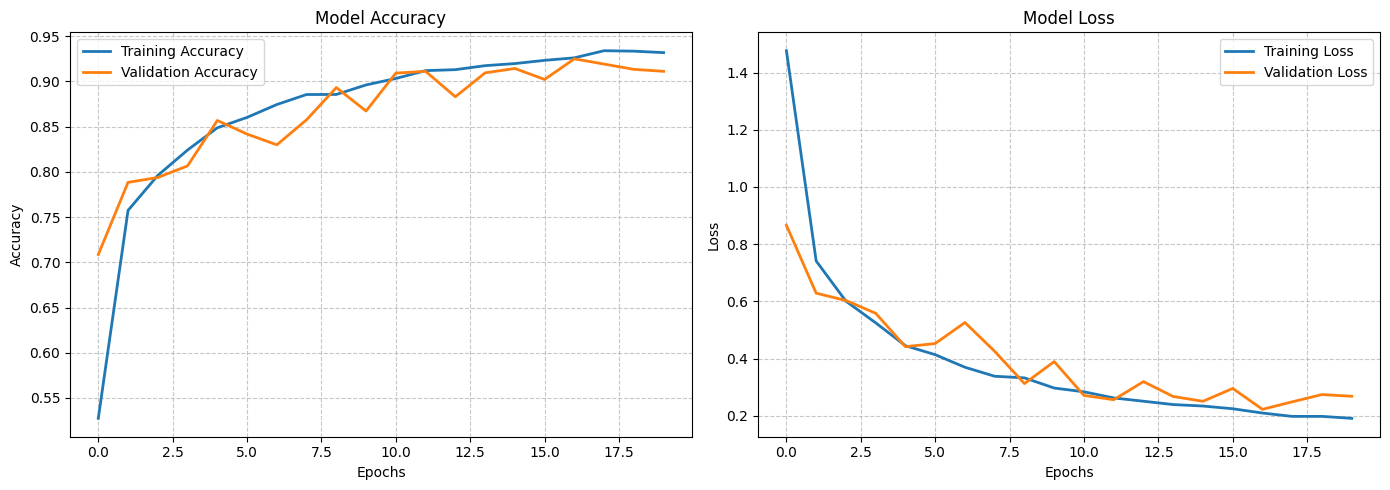

In [7]:
def plot_training_history(history):
    """Plots training and validation metrics across epochs."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy Plot
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2)
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Loss Plot
    axes[1].plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Generate the plots
plot_training_history(history)